# EDA: Credit Score Dataset

Цель ноутбука: провести разведочный анализ `data/train.csv`, проверить качество данных, типы признаков, пропуски, выбросы, распределения, связи признаков с `Credit_Score` и корреляции.


## 1. Импорты и настройки


In [7]:
from pathlib import Path
import math
import re
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:,.3f}".format)

sns.set_theme(style="whitegrid", context="notebook")

TARGET = "Credit_Score"
SCORE_ORDER = ["Poor", "Standard", "Good"]
SCORE_MAP = {"Poor": 0, "Standard": 1, "Good": 2}
SCORE_PALETTE = {"Poor": "#E45756", "Standard": "#4C78A8", "Good": "#54A24B"}
RANDOM_STATE = 42


## 2. Загрузка данных


In [8]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "train.csv"
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
df = df_raw.copy()

display(
    pd.DataFrame(
        {
            "metric": ["path", "rows", "columns"],
            "value": [str(DATA_PATH), f"{df_raw.shape[0]:,}", f"{df_raw.shape[1]:,}"],
        }
    )
)

df_raw.head()


,metric,value
0,path,C:\Users\stoli\PycharmProjects\Credit_score\da...
1,rows,"100,000"
2,columns,28


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,"1,824.843",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.000,_,809.98,26.823,22 Years and 1 Months,No,49.575,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.000,Good,809.98,31.945,NaN,No,49.575,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.000,Good,809.98,28.609,22 Years and 3 Months,No,49.575,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.000,Good,809.98,31.378,22 Years and 4 Months,No,49.575,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,"1,824.843",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.000,Good,809.98,24.797,22 Years and 5 Months,No,49.575,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 3. Первичный обзор


In [9]:
overview = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "duplicate_rows",
            "duplicate_ID",
            "unique_customers",
            "unique_months",
            "target_column",
        ],
        "value": [
            df_raw.shape[0],
            df_raw.shape[1],
            int(df_raw.duplicated().sum()),
            int(df_raw.duplicated("ID").sum()) if "ID" in df_raw else np.nan,
            df_raw["Customer_ID"].nunique() if "Customer_ID" in df_raw else np.nan,
            df_raw["Month"].nunique() if "Month" in df_raw else np.nan,
            TARGET if TARGET in df_raw else "not found",
        ],
    }
)

display(overview)
display(df_raw.sample(5, random_state=RANDOM_STATE))


,metric,value
0,rows,100000
1,columns,28
2,duplicate_rows,0
3,duplicate_ID,0
4,unique_customers,12500
5,unique_months,8
6,target_column,Credit_Score


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
75721,0x1d1af,CUS_0x3539,February,an Arakalid,30,995-31-4669,Manager,43391.96,"3,688.997",1,5,10,0,NaN,9,6,10.72,0.000,Good,1468.28,29.112,23 Years and 8 Months,No,0.000,53.969385063055675,High_spent_Large_value_payments,554.9302816036111,Good
80184,0x1ebd6,CUS_0x8716,January,Matthewz,18,185-99-8068,Scientist,14351.21,NaN,8,7,18,6,"Mortgage Loan, Personal Loan, Not Specified, S...",18,17,21.91,9.000,Bad,4766.87,39.850,NaN,Yes,61.099,118.08021357217683,Low_spent_Small_value_payments,238.3144849566528,Poor
19864,0x8a66,CUS_0x21dc,January,Tom Miless,41,241-53-8475,Developer,130125.04,"10,871.753",5,2,11,2,"Mortgage Loan, and Debt Consolidation Loan",3,0,3.82,645.000,Good,1195.05,21.543,15 Years and 11 Months,No,204.286,1255.8993022448951,Low_spent_Small_value_payments,NaN,Good
76699,0x1d769,CUS_0x32d3,April,Lisaa,35,204-78-6176,Manager,20107.21,"1,631.601",6,6,32,2,"Credit-Builder Loan, and Home Equity Loan",15,13,10.4,11.000,Standard,2544.6,32.424,19 Years and 4 Months,Yes,27.106,66.81977464950728,Low_spent_Small_value_payments,359.23391378882377,Poor
92991,0x236dd,CUS_0xadad,August,Masond,27,027-11-6852,Doctor,92186.19,"7,487.182",1,2,12,4,"Personal Loan, Auto Loan, Not Specified, and P...",1,0,9.74,4.000,Good,809.01,39.543,20 Years and 9 Months,No,185.798,115.52003931707223,High_spent_Medium_value_payments,697.4005568630175,Good


In [10]:
month_distribution = (
    df_raw["Month"]
    .value_counts(dropna=False)
    .rename_axis("Month")
    .reset_index(name="rows")
)

display(month_distribution)


,Month,rows
0,January,12500
1,February,12500
2,March,12500
3,April,12500
4,May,12500
5,June,12500
6,July,12500
7,August,12500


## 4. Типы данных, уникальность и пропуски


In [11]:
profile_raw = pd.DataFrame(
    {
        "dtype": df_raw.dtypes.astype(str),
        "missing": df_raw.isna().sum(),
        "missing_pct": df_raw.isna().mean().mul(100).round(2),
        "n_unique": df_raw.nunique(dropna=True),
        "n_unique_with_nan": df_raw.nunique(dropna=False),
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

display(profile_raw)


,dtype,missing,missing_pct,n_unique,n_unique_with_nan
Monthly_Inhand_Salary,float64,15002,15.000,13235,13236
Type_of_Loan,str,11408,11.410,6260,6261
Name,str,9985,9.980,10139,10140
Credit_History_Age,str,9030,9.030,404,405
Num_of_Delayed_Payment,str,7002,7.000,749,750
Amount_invested_monthly,str,4479,4.480,91049,91050
Num_Credit_Inquiries,float64,1965,1.960,1223,1224
Monthly_Balance,str,1200,1.200,98792,98793
ID,str,0,0.000,100000,100000
Credit_Utilization_Ratio,float64,0,0.000,100000,100000


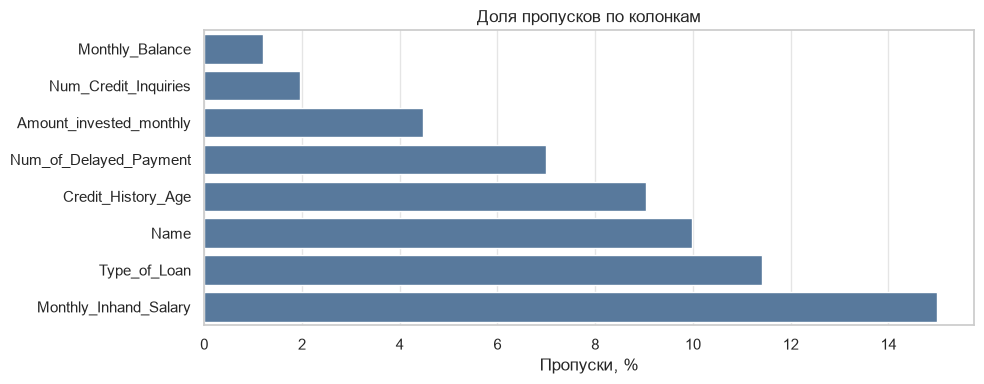

In [12]:
missing_raw = (
    profile_raw.query("missing > 0")
    .sort_values("missing_pct", ascending=True)
    .reset_index(names="column")
)

if missing_raw.empty:
    print("Пропусков не найдено.")
else:
    plt.figure(figsize=(10, max(4, len(missing_raw) * 0.4)))
    sns.barplot(data=missing_raw, x="missing_pct", y="column", color="#4C78A8")
    plt.title("Доля пропусков по колонкам")
    plt.xlabel("Пропуски, %")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


## 5. Распределение целевой переменной


,rows,share_pct
Credit_Score,,
Poor,28998,29.000
Standard,53174,53.170
Good,17828,17.830


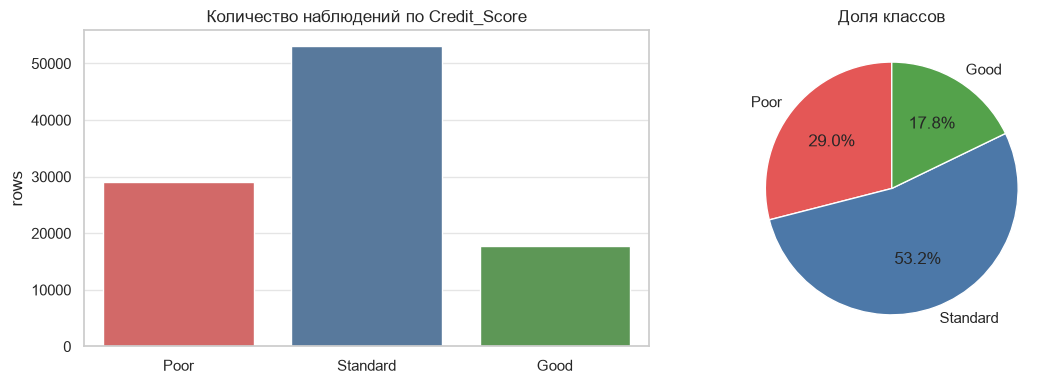

In [13]:
target_counts = df_raw[TARGET].value_counts(dropna=False).reindex(SCORE_ORDER)
target_share = df_raw[TARGET].value_counts(normalize=True, dropna=False).reindex(SCORE_ORDER).mul(100)

target_summary = pd.DataFrame(
    {
        "rows": target_counts,
        "share_pct": target_share.round(2),
    }
)

display(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(
    data=df_raw,
    x=TARGET,
    order=SCORE_ORDER,
    hue=TARGET,
    hue_order=SCORE_ORDER,
    palette=SCORE_PALETTE,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Количество наблюдений по Credit_Score")
axes[0].set_xlabel("")
axes[0].set_ylabel("rows")

axes[1].pie(
    target_counts.fillna(0),
    labels=SCORE_ORDER,
    autopct="%1.1f%%",
    startangle=90,
    colors=[SCORE_PALETTE[label] for label in SCORE_ORDER],
)
axes[1].set_title("Доля классов")
plt.tight_layout()
plt.show()


## 6. Группы признаков и очистка типов

В датасете часть числовых полей хранится как строки из-за подчёркиваний, специальных маркеров и смешанных типов. Для EDA создаётся копия `eda_df`: исходный `df_raw` не изменяется.


In [14]:
ID_COLS = ["ID", "Customer_ID", "Name", "SSN"]

NUMERIC_LIKE_COLS = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

CREDIT_HISTORY_COL = "Credit_History_Age"

DIRECT_NUMERIC_COLS = df_raw.select_dtypes(include="number").columns.tolist()

feature_groups = pd.DataFrame(
    {
        "group": [
            "id_or_personal",
            "direct_numeric",
            "numeric_like_strings",
            "target",
        ],
        "columns": [
            ", ".join([col for col in ID_COLS if col in df_raw]),
            ", ".join(DIRECT_NUMERIC_COLS),
            ", ".join([col for col in NUMERIC_LIKE_COLS if col in df_raw] + [CREDIT_HISTORY_COL]),
            TARGET,
        ],
    }
)

display(feature_groups)


,group,columns
0,id_or_personal,"ID, Customer_ID, Name, SSN"
1,direct_numeric,"Monthly_Inhand_Salary, Num_Bank_Accounts, Num_..."
2,numeric_like_strings,"Age, Annual_Income, Num_of_Loan, Num_of_Delaye..."
3,target,Credit_Score


In [15]:
MISSING_MARKERS = {"", "_", "__", "___", "!@9#%8", "nan", "NaN", "None", "<NA>"}


def normalize_missing_markers(series: pd.Series) -> pd.Series:
    cleaned = series.astype("string").str.strip()
    return cleaned.mask(cleaned.isin(MISSING_MARKERS))


def parse_numeric(series: pd.Series) -> pd.Series:
    cleaned = normalize_missing_markers(series)
    cleaned = cleaned.str.replace("_", "", regex=False)
    return pd.to_numeric(cleaned, errors="coerce")


def parse_credit_history_to_months(series: pd.Series) -> pd.Series:
    cleaned = normalize_missing_markers(series)
    parts = cleaned.str.extract(
        r"(?:(\d+)\s+Years?)?\s*(?:and\s*)?(?:(\d+)\s+Months?)?",
        expand=True,
    )
    years = pd.to_numeric(parts[0], errors="coerce")
    months = pd.to_numeric(parts[1], errors="coerce")
    parsed = years.fillna(0).mul(12).add(months.fillna(0))
    return parsed.where(parts.notna().any(axis=1))


def clean_credit_dataframe(input_df: pd.DataFrame) -> pd.DataFrame:
    data = input_df.copy()

    for column in data.select_dtypes(include=["object", "string"]).columns:
        data[column] = normalize_missing_markers(data[column])

    for column in NUMERIC_LIKE_COLS:
        if column in data.columns:
            data[column] = parse_numeric(data[column])

    if CREDIT_HISTORY_COL in data.columns:
        data["Credit_History_Age_Months"] = parse_credit_history_to_months(data[CREDIT_HISTORY_COL])

    if TARGET in data.columns:
        data[TARGET] = pd.Categorical(data[TARGET], categories=SCORE_ORDER, ordered=True)
        data["Credit_Score_Num"] = data[TARGET].map(SCORE_MAP).astype(float)

    return data


eda_df = clean_credit_dataframe(df_raw)
eda_df.head()


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Age_Months,Credit_Score_Num
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.120","1,824.843",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.270,4.000,<NA>,809.980,26.823,22 Years and 1 Months,No,49.575,80.415,High_spent_Small_value_payments,312.494,Good,265,2.000
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.120",NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,<NA>,11.270,4.000,Good,809.980,31.945,<NA>,No,49.575,118.280,Low_spent_Large_value_payments,284.629,Good,<NA>,2.000
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,"19,114.120",NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,<NA>,4.000,Good,809.980,28.609,22 Years and 3 Months,No,49.575,81.700,Low_spent_Medium_value_payments,331.210,Good,267,2.000
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.120",NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.270,4.000,Good,809.980,31.378,22 Years and 4 Months,No,49.575,199.458,Low_spent_Small_value_payments,223.451,Good,268,2.000
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,"19,114.120","1,824.843",3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,<NA>,11.270,4.000,Good,809.980,24.797,22 Years and 5 Months,No,49.575,41.420,High_spent_Medium_value_payments,341.489,Good,269,2.000


In [16]:
profile_clean = pd.DataFrame(
    {
        "dtype_raw": df_raw.dtypes.astype(str),
        "dtype_eda": eda_df.dtypes.astype(str),
        "missing_raw": df_raw.isna().sum(),
        "missing_eda": eda_df.isna().sum(),
        "missing_eda_pct": eda_df.isna().mean().mul(100).round(2),
        "n_unique_eda": eda_df.nunique(dropna=True),
    }
).sort_values(["missing_eda_pct", "n_unique_eda"], ascending=[False, False])

display(profile_clean)


,dtype_raw,dtype_eda,missing_raw,missing_eda,missing_eda_pct,n_unique_eda
Credit_Mix,str,string,0.000,20195,20.200,3
Monthly_Inhand_Salary,float64,float64,"15,002.000",15002,15.000,13235
Type_of_Loan,str,string,"11,408.000",11408,11.410,6260
Name,str,string,"9,985.000",9985,9.980,10136
Credit_History_Age,str,string,"9,030.000",9030,9.030,404
Credit_History_Age_Months,NaN,Int64,NaN,9030,9.030,404
Payment_Behaviour,str,string,0.000,7600,7.600,6
Num_of_Delayed_Payment,str,Int64,"7,002.000",7002,7.000,711
Amount_invested_monthly,str,Float64,"4,479.000",4479,4.480,91049
Changed_Credit_Limit,str,Float64,0.000,2091,2.090,4375


## 7. Числовая статистика и аномалии


In [17]:
eda_numeric_cols = [
    column
    for column in eda_df.select_dtypes(include="number").columns
    if column != "Credit_Score_Num"
]

numeric_summary = eda_df[eda_numeric_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

display(numeric_summary)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Age,"100,000.000",110.650,686.245,-500.000,14.000,16.000,24.000,33.000,42.000,53.000,"4,112.070","8,698.000"
Annual_Income,"100,000.000","176,415.701","1,429,618.051","7,005.930","7,535.997","9,743.510","19,457.500","37,578.610","72,790.920","134,533.320","179,987.280","24,198,062.000"
Monthly_Inhand_Salary,"84,998.000","4,194.171","3,183.686",303.645,531.875,836.126,"1,625.568","3,093.745","5,957.448","10,828.226","13,814.930","15,204.633"
Num_Bank_Accounts,"100,000.000",17.091,117.405,-1.000,0.000,1.000,3.000,6.000,7.000,10.000,445.010,"1,798.000"
Num_Credit_Card,"100,000.000",22.474,129.057,0.000,1.000,3.000,4.000,5.000,7.000,10.000,849.000,"1,499.000"
Interest_Rate,"100,000.000",72.466,466.423,1.000,1.000,2.000,8.000,13.000,20.000,33.000,"2,865.010","5,797.000"
Num_of_Loan,"100,000.000",3.010,62.648,-100.000,-100.000,0.000,1.000,3.000,5.000,8.000,9.000,"1,496.000"
Delay_from_due_date,"100,000.000",21.069,14.860,-5.000,0.000,3.000,10.000,18.000,28.000,54.000,61.000,67.000
Num_of_Delayed_Payment,"92,998.000",30.923,226.032,-3.000,0.000,2.000,9.000,14.000,18.000,24.000,27.000,"4,397.000"
Changed_Credit_Limit,"97,909.000",10.389,6.789,-6.490,-1.540,1.160,5.320,9.400,14.870,23.600,28.810,36.970


In [18]:
expected_ranges = {
    "Age": (18, 100),
    "Annual_Income": (0, 1_000_000),
    "Monthly_Inhand_Salary": (0, 100_000),
    "Num_Bank_Accounts": (0, 20),
    "Num_Credit_Card": (0, 20),
    "Interest_Rate": (0, 100),
    "Num_of_Loan": (0, 20),
    "Delay_from_due_date": (0, 90),
    "Num_of_Delayed_Payment": (0, 100),
    "Num_Credit_Inquiries": (0, 100),
    "Outstanding_Debt": (0, 20_000),
    "Total_EMI_per_month": (0, 20_000),
    "Amount_invested_monthly": (0, 20_000),
    "Monthly_Balance": (0, 10_000),
    "Credit_History_Age_Months": (0, 600),
}

anomaly_rows = []
for column, (lower, upper) in expected_ranges.items():
    if column not in eda_df:
        continue
    series = eda_df[column]
    mask = series.notna() & ((series < lower) | (series > upper))
    anomaly_rows.append(
        {
            "column": column,
            "expected_min": lower,
            "expected_max": upper,
            "out_of_range": int(mask.sum()),
            "out_of_range_pct": round(mask.mean() * 100, 2),
            "min": series.min(),
            "p01": series.quantile(0.01),
            "median": series.median(),
            "p99": series.quantile(0.99),
            "max": series.max(),
        }
    )

anomaly_summary = (
    pd.DataFrame(anomaly_rows)
    .sort_values(["out_of_range_pct", "out_of_range"], ascending=False)
    .reset_index(drop=True)
)

display(anomaly_summary)


,column,expected_min,expected_max,out_of_range,out_of_range_pct,min,p01,median,p99,max
0,Age,18,100,8482,8.480,-500.000,14.000,33.000,"4,112.070","8,698.000"
1,Num_of_Loan,0,20,4345,4.350,-100.000,-100.000,3.000,9.000,"1,496.000"
2,Total_EMI_per_month,0,20000,2390,2.390,0.000,0.000,69.249,"56,125.300","82,331.000"
3,Num_Credit_Card,0,20,2263,2.260,0.000,1.000,5.000,849.000,"1,499.000"
4,Interest_Rate,0,100,2012,2.010,1.000,1.000,13.000,"2,865.010","5,797.000"
5,Num_Credit_Inquiries,0,100,1602,1.600,0.000,0.000,6.000,"1,109.280","2,597.000"
6,Num_of_Delayed_Payment,0,100,1368,1.370,-3.000,0.000,14.000,27.000,"4,397.000"
7,Num_Bank_Accounts,0,20,1335,1.340,-1.000,0.000,6.000,445.010,"1,798.000"
8,Annual_Income,0,1000000,961,0.960,"7,005.930","7,535.997","37,578.610","179,987.280","24,198,062.000"
9,Delay_from_due_date,0,90,591,0.590,-5.000,0.000,18.000,61.000,67.000


## 8. Распределения числовых признаков

Гистограммы ниже клиппируются по 1% и 99% квантилям только для читаемости графика. Это не изменяет `eda_df`.


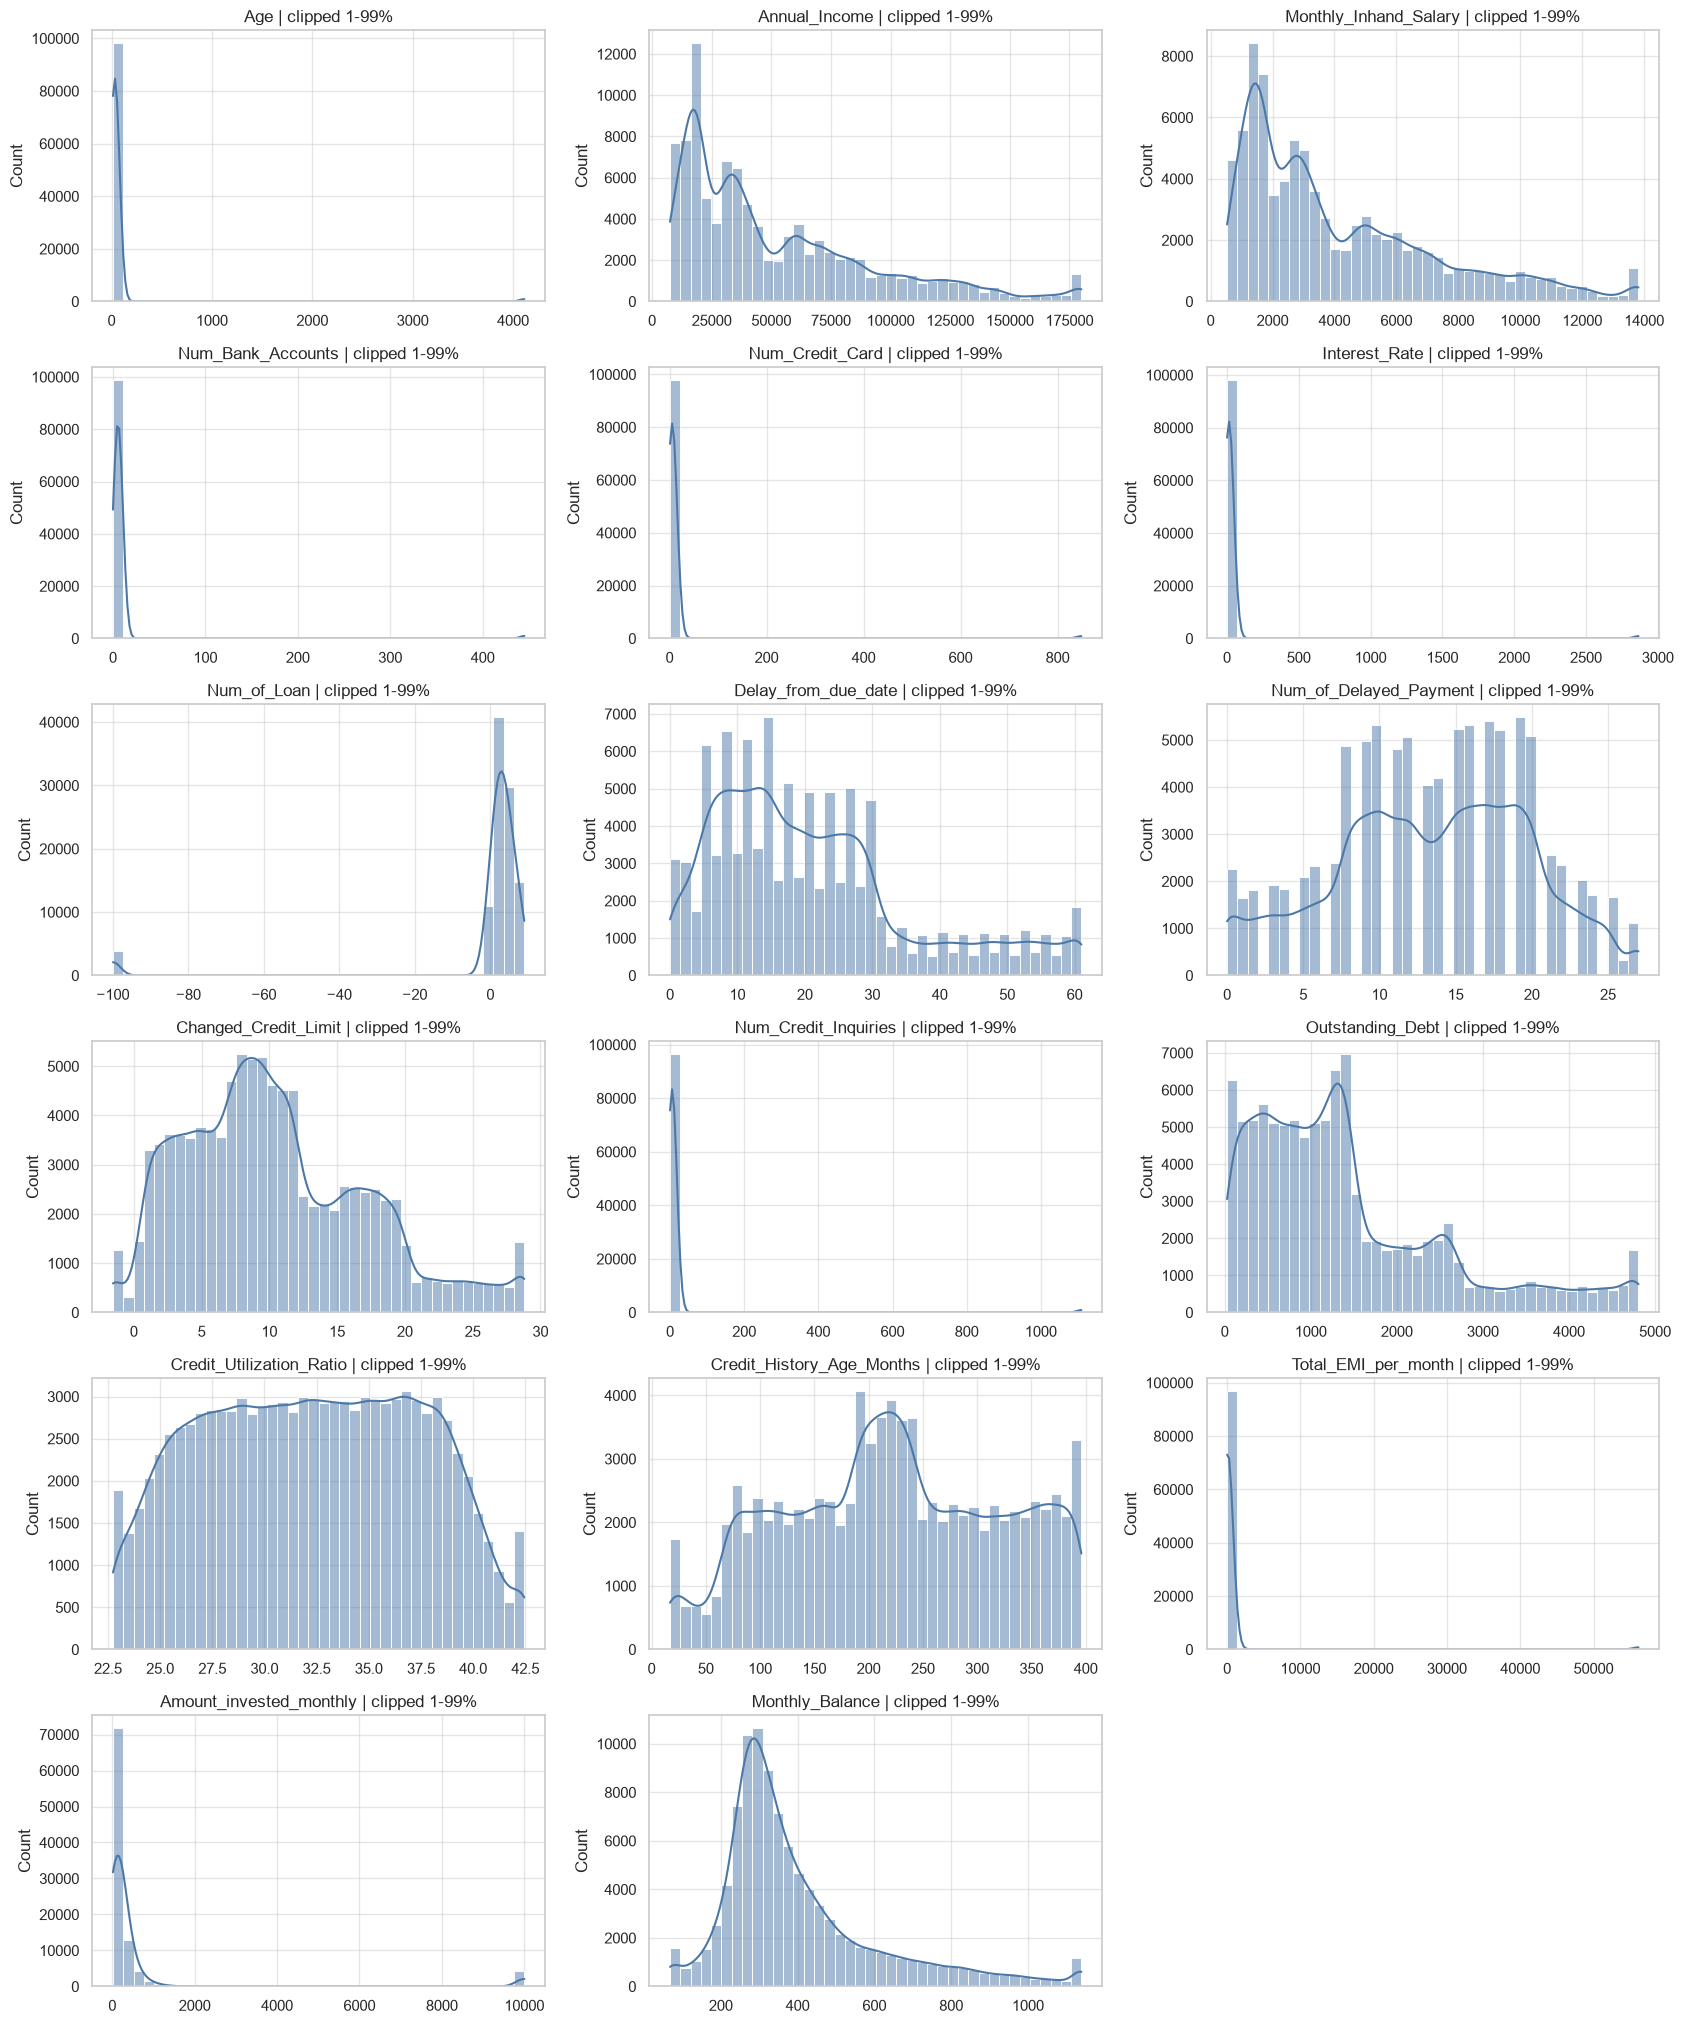

In [19]:
important_numeric = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Credit_History_Age_Months",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
]
plot_numeric = [column for column in important_numeric if column in eda_numeric_cols]

n_cols = 3
n_rows = math.ceil(len(plot_numeric) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, max(4, n_rows * 3.4)))
axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, plot_numeric):
    series = pd.to_numeric(eda_df[column], errors='coerce').astype(float).dropna()
    if series.empty:
        ax.set_visible(False)
        continue
    lower, upper = series.quantile([0.01, 0.99])
    plot_series = series.clip(lower, upper)
    sns.histplot(plot_series, kde=True, bins=40, color="#4C78A8", ax=ax)
    ax.set_title(f"{column} | clipped 1-99%")
    ax.set_xlabel("")

for ax in axes[len(plot_numeric):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 9. Boxplot для поиска выбросов


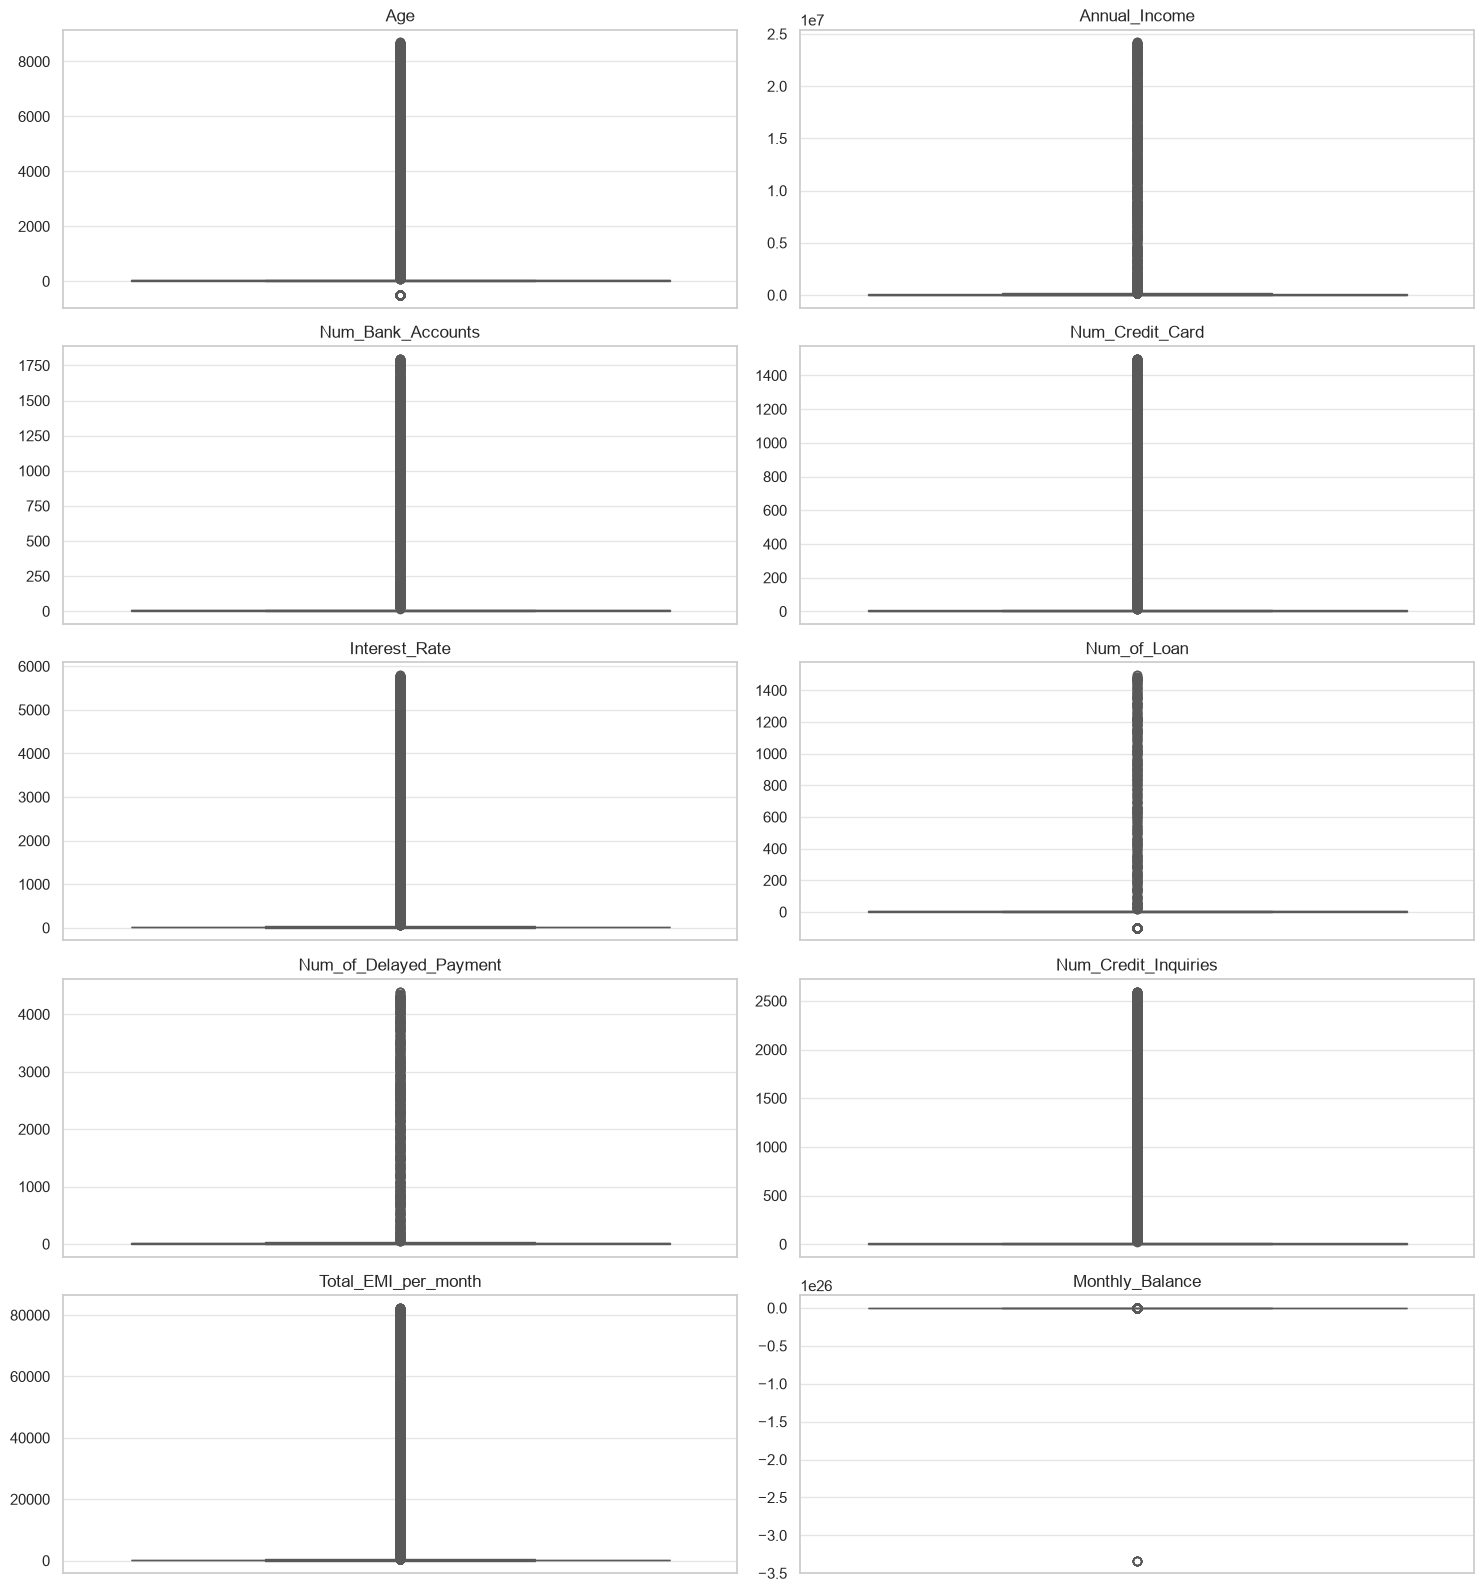

In [20]:
boxplot_cols = [
    "Age",
    "Annual_Income",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Total_EMI_per_month",
    "Monthly_Balance",
]
boxplot_cols = [column for column in boxplot_cols if column in eda_numeric_cols]

n_cols = 2
n_rows = math.ceil(len(boxplot_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, n_rows * 3.2)))
axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, boxplot_cols):
    sns.boxplot(y=eda_df[column], color="#72B7B2", ax=ax)
    ax.set_title(column)
    ax.set_ylabel("")

for ax in axes[len(boxplot_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


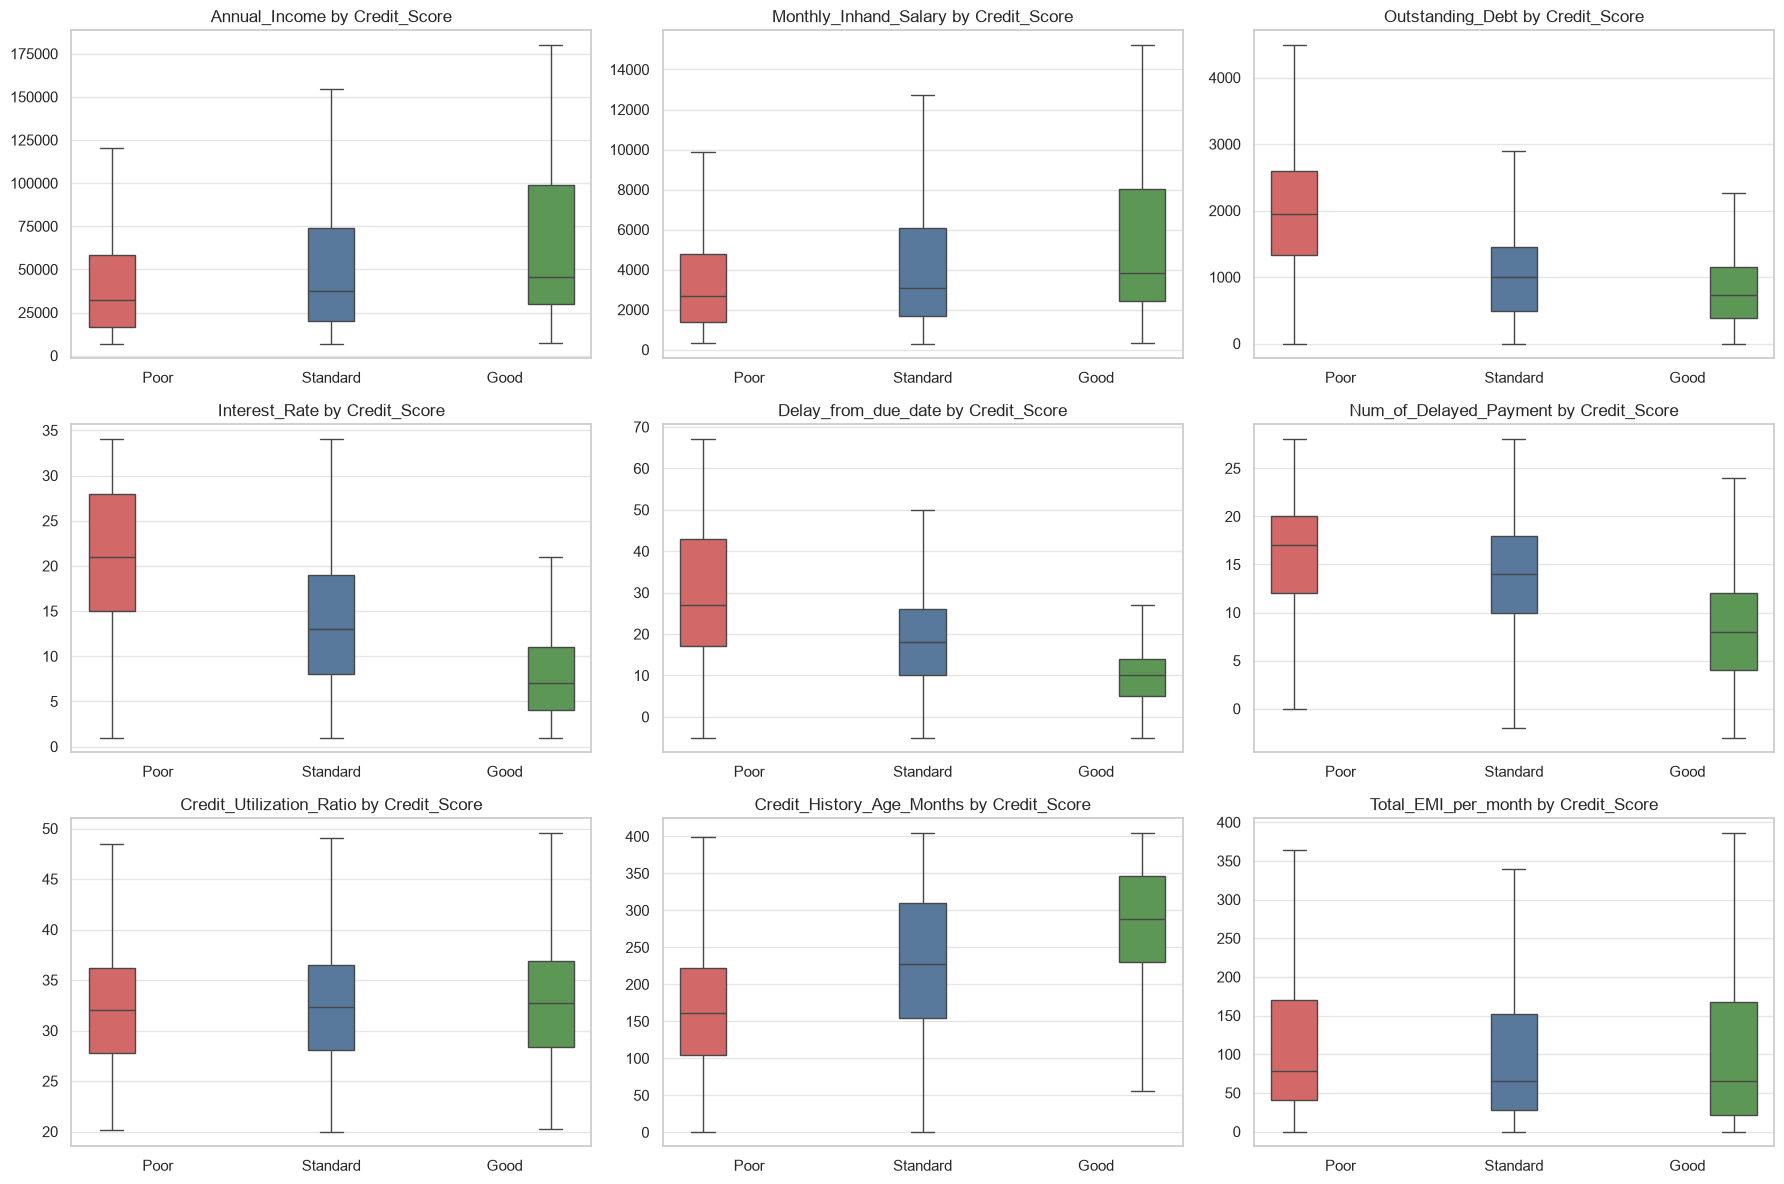

In [21]:
box_by_target_cols = [
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Outstanding_Debt",
    "Interest_Rate",
    "Delay_from_due_date",
    "Num_of_Delayed_Payment",
    "Credit_Utilization_Ratio",
    "Credit_History_Age_Months",
    "Total_EMI_per_month",
]
box_by_target_cols = [column for column in box_by_target_cols if column in eda_numeric_cols]

n_cols = 3
n_rows = math.ceil(len(box_by_target_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, max(4, n_rows * 4)))
axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, box_by_target_cols):
    sns.boxplot(
        data=eda_df,
        x=TARGET,
        y=column,
        order=SCORE_ORDER,
        hue=TARGET,
        hue_order=SCORE_ORDER,
        palette=SCORE_PALETTE,
        showfliers=False,
        legend=False,
        ax=ax,
    )
    ax.set_title(f"{column} by {TARGET}")
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(box_by_target_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 10. Категориальные признаки


In [22]:
categorical_cols = [
    column
    for column in eda_df.select_dtypes(include=["object", "string", "category"]).columns
    if column not in ID_COLS + [TARGET, CREDIT_HISTORY_COL, "Type_of_Loan"]
]
low_cardinality_cols = [
    column
    for column in categorical_cols
    if eda_df[column].nunique(dropna=True) <= 20
]

category_profile = pd.DataFrame(
    {
        "column": categorical_cols,
        "n_unique": [eda_df[column].nunique(dropna=True) for column in categorical_cols],
        "missing_pct": [eda_df[column].isna().mean() * 100 for column in categorical_cols],
    }
).sort_values("n_unique")

display(category_profile)
display(pd.DataFrame({"low_cardinality_for_plots": low_cardinality_cols}))


,column,n_unique,missing_pct
3,Payment_of_Min_Amount,3,0.000
2,Credit_Mix,3,20.195
4,Payment_Behaviour,6,7.600
0,Month,8,0.000
1,Occupation,16,0.000


,low_cardinality_for_plots
0,Month
1,Occupation
2,Credit_Mix
3,Payment_of_Min_Amount
4,Payment_Behaviour


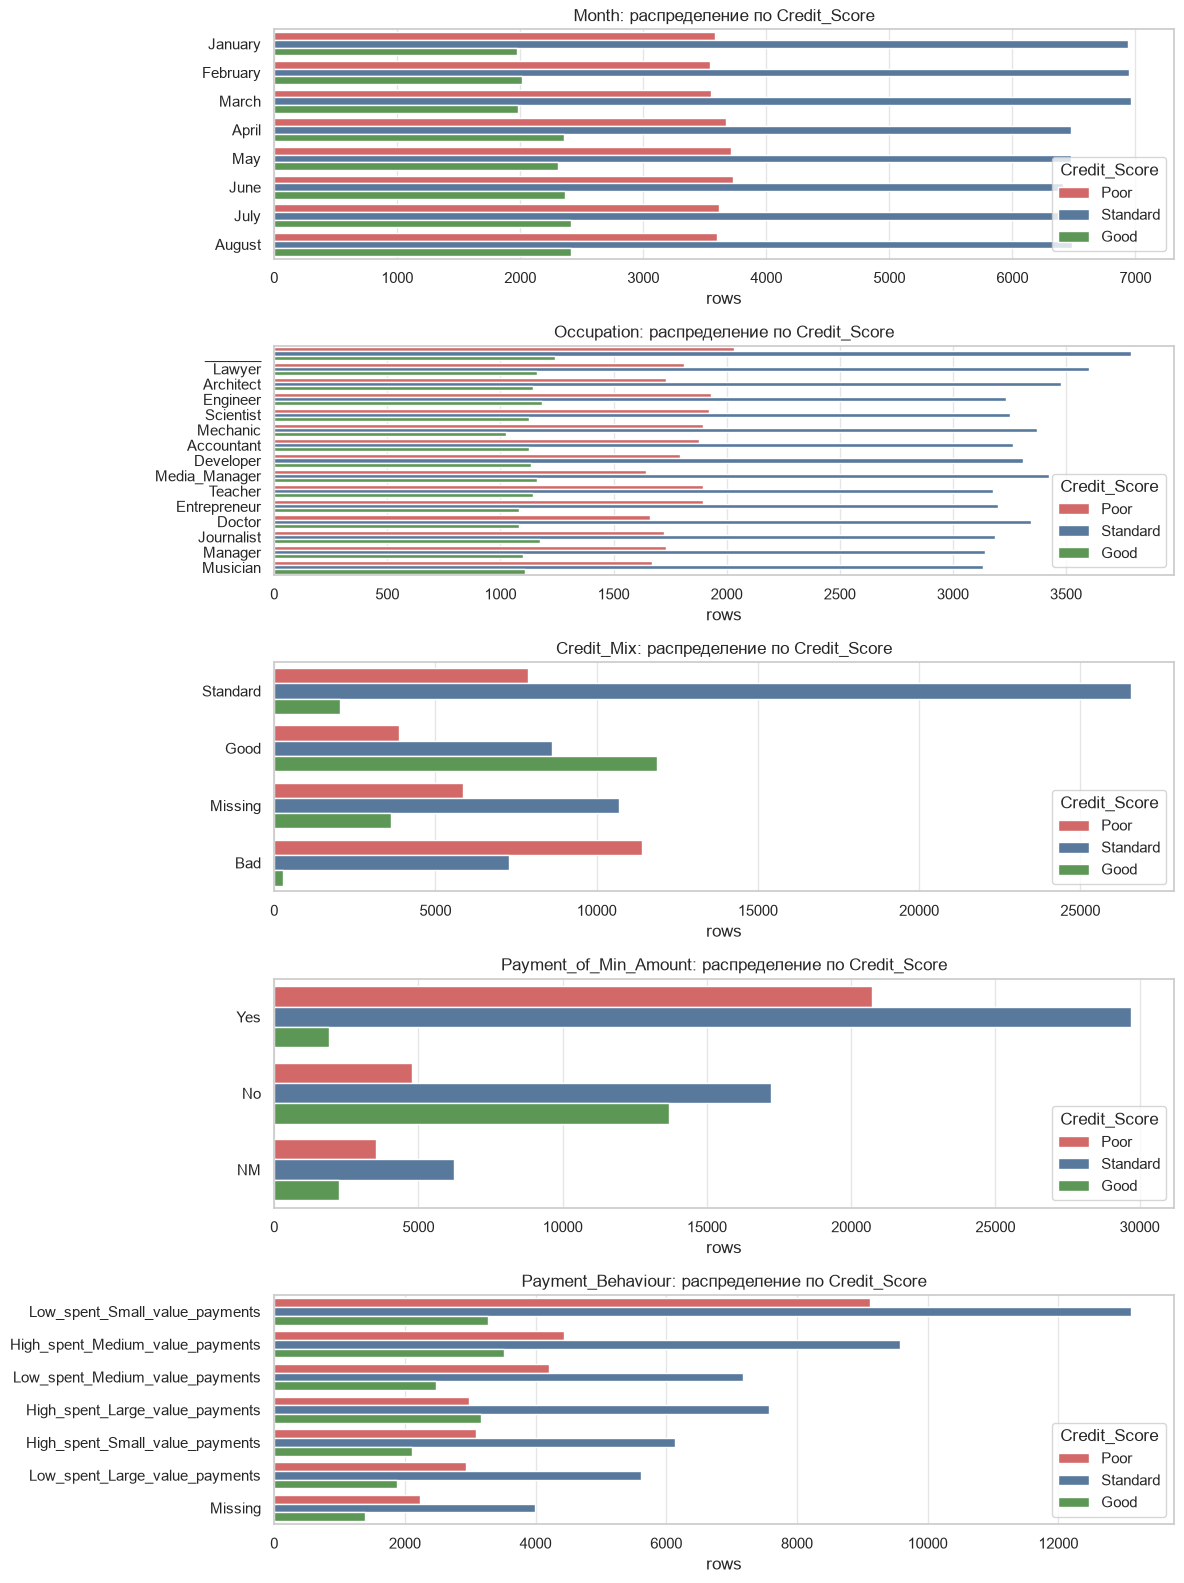

In [23]:
if not low_cardinality_cols:
    print("Нет категориальных признаков с низкой кардинальностью для компактного графика.")
else:
    n_rows = len(low_cardinality_cols)
    fig, axes = plt.subplots(n_rows, 1, figsize=(12, max(4, n_rows * 3.2)))
    axes = np.array(axes).reshape(-1)

    for ax, column in zip(axes, low_cardinality_cols):
        plot_data = eda_df[[column, TARGET]].copy()
        plot_data[column] = plot_data[column].astype("string").fillna("Missing").astype(str)
        order = plot_data[column].value_counts().index[:15]

        sns.countplot(
            data=plot_data,
            y=column,
            order=order,
            hue=TARGET,
            hue_order=SCORE_ORDER,
            palette=SCORE_PALETTE,
            ax=ax,
        )
        ax.set_title(f"{column}: распределение по {TARGET}")
        ax.set_xlabel("rows")
        ax.set_ylabel("")
        ax.legend(title=TARGET, loc="lower right")

    plt.tight_layout()
    plt.show()


In [24]:
target_rate_cols = [column for column in low_cardinality_cols if eda_df[column].nunique(dropna=True) > 1]

for column in target_rate_cols:
    rate_data = eda_df[[column, TARGET]].copy()
    rate_data[column] = rate_data[column].astype("string").fillna("Missing").astype(str)

    counts = rate_data[column].value_counts(dropna=False)
    rates = (
        pd.crosstab(rate_data[column], rate_data[TARGET], normalize="index")
        .reindex(columns=SCORE_ORDER)
        .fillna(0)
    )
    rates = rates.loc[counts.index.intersection(rates.index)]
    rates["rows"] = counts.loc[rates.index]
    rates_display = rates.sort_values("rows", ascending=False).head(15).copy()
    rates_display[SCORE_ORDER] = rates_display[SCORE_ORDER].mul(100).round(2)
    rates_display = rates_display.rename(columns={score: f"{score}_pct" for score in SCORE_ORDER})
    display(rates_display)


Credit_Score,Poor_pct,Standard_pct,Good_pct,rows
Month,,,,
January,28.660,55.540,15.800,12500
February,28.310,55.560,16.130,12500
March,28.410,55.720,15.870,12500
April,29.360,51.780,18.860,12500
May,29.700,51.820,18.480,12500
June,29.820,51.280,18.900,12500
July,28.910,51.800,19.290,12500
August,28.820,51.880,19.300,12500


Credit_Score,Poor_pct,Standard_pct,Good_pct,rows
Occupation,,,,
_______,28.760,53.640,17.600,7062
Lawyer,27.530,54.800,17.670,6575
Architect,27.290,54.710,18.000,6355
Engineer,30.430,50.960,18.610,6350
Scientist,30.500,51.610,17.890,6299
Mechanic,30.140,53.580,16.280,6291
Accountant,29.960,52.050,17.990,6271
Developer,28.740,53.070,18.190,6235
Media_Manager,26.400,54.970,18.630,6232


Credit_Score,Poor_pct,Standard_pct,Good_pct,rows
Credit_Mix,,,,
Standard,21.540,72.860,5.600,36479
Good,15.860,35.340,48.790,24337
Missing,29.060,53.000,17.940,20195
Bad,60.080,38.400,1.520,18989


Credit_Score,Poor_pct,Standard_pct,Good_pct,rows
Payment_of_Min_Amount,,,,
Yes,39.570,56.770,3.650,52326
No,13.380,48.290,38.330,35667
NM,29.300,52.000,18.700,12007


Credit_Score,Poor_pct,Standard_pct,Good_pct,rows
Payment_Behaviour,,,,
Low_spent_Small_value_payments,35.770,51.410,12.830,25513
High_spent_Medium_value_payments,25.310,54.600,20.090,17540
Low_spent_Medium_value_payments,30.380,51.710,17.910,13861
High_spent_Large_value_payments,21.710,55.170,23.120,13721
High_spent_Small_value_payments,27.230,54.130,18.640,11340
Low_spent_Large_value_payments,28.120,53.850,18.030,10425
Missing,29.280,52.530,18.200,7600


## 11. Корреляция

Для корреляций используется Spearman, потому что в данных много выбросов и порядковых/счётных признаков. `Credit_Score` временно кодируется как `Poor=0`, `Standard=1`, `Good=2`.


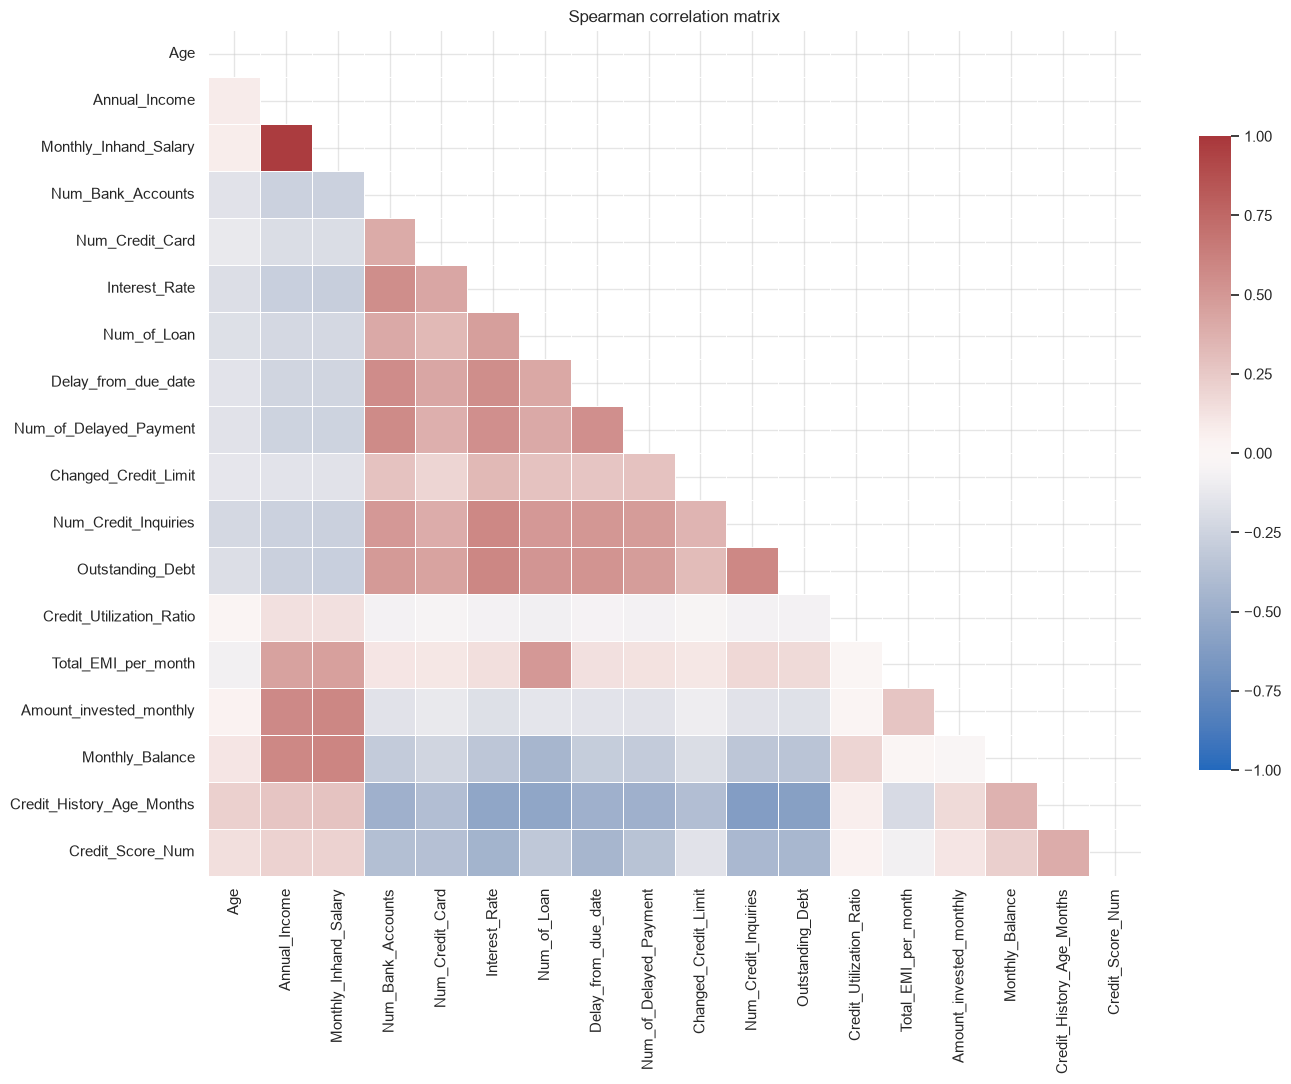

In [25]:
corr_numeric_cols = [
    column
    for column in eda_numeric_cols
    if eda_df[column].nunique(dropna=True) > 1
]

corr_input = eda_df[corr_numeric_cols + ["Credit_Score_Num"]]
corr_matrix = corr_input.corr(method="spearman")

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75},
)
plt.title("Spearman correlation matrix")
plt.tight_layout()
plt.show()


In [26]:
target_corr = (
    corr_matrix["Credit_Score_Num"]
    .drop("Credit_Score_Num")
    .dropna()
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

target_corr_table = pd.DataFrame(
    {
        "spearman_corr_with_credit_score": target_corr,
        "abs_corr": target_corr.abs(),
    }
)

display(target_corr_table.head(15))


,spearman_corr_with_credit_score,abs_corr
Interest_Rate,-0.460,0.460
Delay_from_due_date,-0.438,0.438
Outstanding_Debt,-0.434,0.434
Num_Credit_Inquiries,-0.423,0.423
Credit_History_Age_Months,0.398,0.398
Num_Bank_Accounts,-0.378,0.378
Num_Credit_Card,-0.367,0.367
Num_of_Delayed_Payment,-0.358,0.358
Num_of_Loan,-0.324,0.324
Monthly_Balance,0.225,0.225


## 12. Scatterplot для наиболее связанных числовых признаков


,feature_1,feature_2,abs_spearman_corr
0,Annual_Income,Monthly_Inhand_Salary,0.975
1,Num_Credit_Inquiries,Credit_History_Age_Months,0.611
2,Monthly_Inhand_Salary,Monthly_Balance,0.599
3,Outstanding_Debt,Credit_History_Age_Months,0.597
4,Monthly_Inhand_Salary,Amount_invested_monthly,0.590
5,Interest_Rate,Outstanding_Debt,0.587
6,Annual_Income,Monthly_Balance,0.584
7,Interest_Rate,Num_Credit_Inquiries,0.581
8,Num_Credit_Inquiries,Outstanding_Debt,0.578
9,Annual_Income,Amount_invested_monthly,0.574


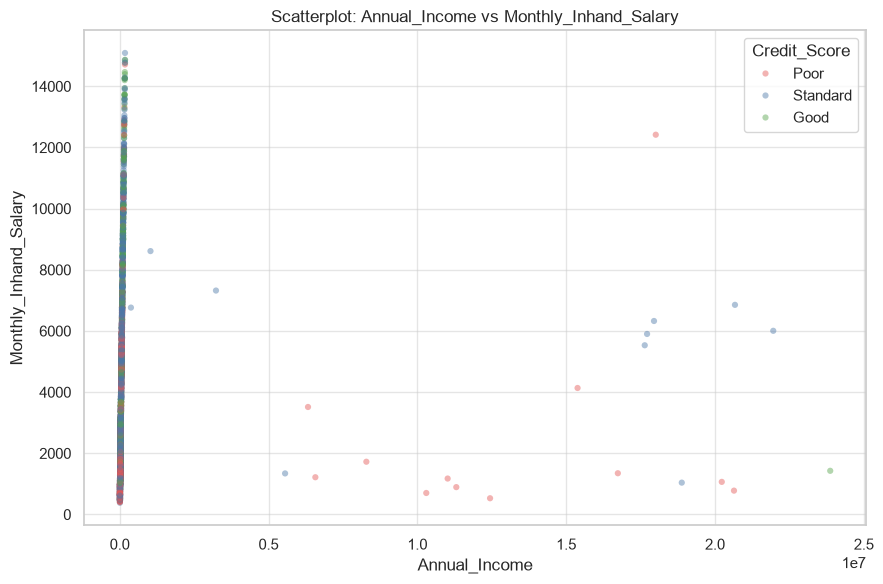

In [27]:
pair_corr = corr_matrix.loc[corr_numeric_cols, corr_numeric_cols].abs()
upper_mask = np.triu(np.ones(pair_corr.shape, dtype=bool), k=1)
top_pairs = pair_corr.where(upper_mask).stack().sort_values(ascending=False).head(10)

top_pairs_table = top_pairs.rename("abs_spearman_corr").reset_index()
top_pairs_table.columns = ["feature_1", "feature_2", "abs_spearman_corr"]
display(top_pairs_table)

if top_pairs.empty:
    print("Недостаточно числовых признаков для scatterplot.")
else:
    x_feature, y_feature = top_pairs.index[0]
    sample = eda_df.sample(min(3_000, len(eda_df)), random_state=RANDOM_STATE)

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=sample,
        x=x_feature,
        y=y_feature,
        hue=TARGET,
        hue_order=SCORE_ORDER,
        palette=SCORE_PALETTE,
        alpha=0.45,
        s=20,
        linewidth=0,
    )
    plt.title(f"Scatterplot: {x_feature} vs {y_feature}")
    plt.tight_layout()
    plt.show()


## 13. Предварительные выводы

- В данных 100 000 строк, 28 исходных колонок, 12 500 клиентов и 8 месяцев наблюдений.
- `ID` уникален, а `Customer_ID`, `Name`, `SSN` и похожие идентификаторы не стоит использовать как обычные числовые признаки.
- Целевая переменная несбалансирована: больше всего класса `Standard`, меньше всего `Good`.
- Значительная часть числовых признаков изначально хранится как строки; без очистки корреляции и boxplot будут неполными или искажёнными.
- Есть явные аномалии и служебные значения: отрицательный возраст, экстремально большие значения банковских счетов, кредитных карт, ставок, EMI и один огромный отрицательный `Monthly_Balance`.
- Перед моделированием нужно отдельно выбрать стратегию обработки аномалий и пропусков: удаление, winsorization/clip, импутация по клиенту или по группам признаков.


## 14. Краткий отчёт о данных

Датасет описывает кредитное поведение клиентов за период с января по август. В выборке 100 000 наблюдений, 28 исходных признаков и 12 500 уникальных клиентов; на каждого клиента приходится несколько месячных записей. Целевая переменная `Credit_Score` имеет три класса: `Standard` — 53.17%, `Poor` — 29.00%, `Good` — 17.83%, поэтому при обучении модели нужно учитывать умеренный дисбаланс классов.

Качество данных требует предварительной обработки. Наиболее заметные пропуски есть в `Monthly_Inhand_Salary` — 15.00%, `Type_of_Loan` — 11.41%, `Name` — 9.98%, `Credit_History_Age` — 9.03%, `Num_of_Delayed_Payment` — 7.00%, `Amount_invested_monthly` — 4.48%, `Num_Credit_Inquiries` — 1.96% и `Monthly_Balance` — 1.20%. Часть числовых признаков прочиталась как строки из-за служебных символов и значений, поэтому перед корреляциями, boxplot и моделированием их нужно приводить к числовому типу.

EDA выявил выраженные аномалии: отрицательные значения возраста и задержек платежей, экстремально большие значения количества банковских счетов, кредитных карт, процентной ставки, числа кредитных запросов, EMI и единичное крайне отрицательное значение `Monthly_Balance`. Такие наблюдения нельзя автоматически считать ошибками без бизнес-проверки, но для базовой модели их стоит обработать через правила допустимых диапазонов, клиппинг по квантилям или импутацию по клиенту/группам.

Наиболее связанные с `Credit_Score` числовые признаки по Spearman: `Interest_Rate` (-0.460), `Delay_from_due_date` (-0.438), `Outstanding_Debt` (-0.434), `Num_Credit_Inquiries` (-0.423), `Credit_History_Age_Months` (0.398), `Num_Bank_Accounts` (-0.378), `Num_Credit_Card` (-0.367), `Num_of_Delayed_Payment` (-0.358), `Num_of_Loan` (-0.324) и `Monthly_Balance` (0.225). Направление связи логично: высокий долг, задержки, частые кредитные запросы и высокая ставка чаще соответствуют худшему кредитному рейтингу, а более длинная кредитная история и больший месячный баланс чаще связаны с лучшим рейтингом.

Итог: данные подходят для задачи классификации кредитного рейтинга, но перед построением модели нужен отдельный preprocessing pipeline: очистка строковых числовых колонок, обработка пропусков, фильтрация или клиппинг аномалий, исключение идентификаторов (`ID`, `Customer_ID`, `Name`, `SSN`) из обычных признаков и аккуратное кодирование категориальных переменных.
